[SciPy](http://scipy.org/scipylib/index.html) je v současnosti největší a v podstatě referenční knihovnou, obsahující nástroje pro vědecké výpočty. Najdeme v ní např. speciální funkce, interpolace, Fourierovu transformaci, numerické integrátory a mnohé další. Naším cílem bude ukázat některé z funkcí SciPy.
<!-- TEASER_END -->

Tento notebook byl z (velké) části převzat a přeložen z J.R. Johansson: [Lectures on scientific computing with Python](http://github.com/jrjohansson/scientific-python-lectures) - díky.

## Přehled SciPy

SciPy staví na NumPy a poskytuje mnoho funkcí "vyšší úrovně" pro vědecké výpočty. Ve SciPy je asi dvacet modulů, každý z těchto modulů obsahuje mnoho funkcí a/nebo tříd pro danou oblast.

In [1]:
from IPython.display import HTML
HTML('<iframe src=http://docs.scipy.org/doc/scipy/reference/index.html width=900 height=450></iframe>')

## Import SciPy

In [2]:
# toto už známe
# budeme potřebovat numpy a matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [3]:
# toto je typický import scipy
import scipy as sp

## Něco na zahřátí -- speciální funkce

Speciální funkce jsou často řešením vědeckých úloh. Jejich implementace je v mnoha případech poměrně náročná. Proto existují knihovny jako je `scipy.special`: http://docs.scipy.org/doc/scipy/reference/special.html#module-scipy.special. 

Podíváme se např. na Besselovy funkce.

In [4]:
from scipy.special import jn, yn, jn_zeros, yn_zeros

Jednoduché vyčíslení funkcí s daným vstupem.

In [5]:
n = 0    # order
x = 0.0

# Bessel function of first kind
print("J_%d(%f) = %f" % (n, x, jn(n, x)))

x = 1.0
# Bessel function of second kind
print("Y_%d(%f) = %f" % (n, x, yn(n, x)))

J_0(0.000000) = 1.000000
Y_0(1.000000) = 0.088257


Funkce jsou samozřejmě vektorové, pomocí `matplotlib` si jednoduše nakreslíme graf.

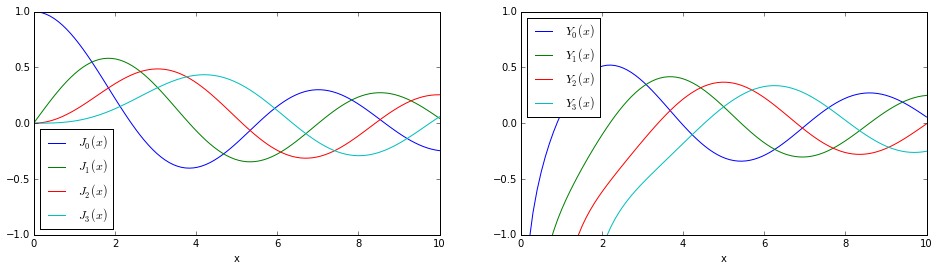

In [6]:
x = linspace(0, 10, 100)

fig, ax = subplots(1, 2, figsize=(16,4))
for i, (func, label) in enumerate(zip((jn, yn), (r"$J_%d(x)$", r"$Y_%d(x)$"))):
    for n in range(4):
        ax[i].plot(x, func(n, x), label=label % n)
    ax[i].legend(loc="best")
    ax[i].set_xlabel("x")
    ax[i].set_ylim(-1, 1)

Zkusíme najíd kořeny Besselových funkcí

In [7]:
n = 0  # order
m = 4  # number of roots to compute
sol = jn_zeros(n, m)
print(sol)
# zkouška
print(jn(n, sol))
# využijeme allclose
print(allclose(jn(n, sol), 0))

[  2.40482556   5.52007811   8.65372791  11.79153444]
[ -1.02392318e-16  -1.41172448e-17   1.30044207e-17  -1.43819206e-16]
True


## Numerická integrace

### Vyčíslení určitého integrálu
Numerical evaluation of a function of the type
Často potřebujeme numericky vyčíslit určitý integrál, tj.

$\displaystyle \int_a^b f(x) {\rm d}x$

Numerické integraci se často říká kvadratura, anglicky *quadrature*. Podle toho se jmenují o funkce v modulu `scipy.integrate`, např. `quad`, `dblquad`, `tplquad` nebo obecné `nquad`.

In [8]:
from scipy.integrate import quad, dblquad, tplquad

Zkusíme spočítat jednodychý integrál:

$\displaystyle \int_0^1 x {\rm d}x$

In [9]:
val, abserr = quad(lambda x: x, 0, 1)
print(u"výsledek = {:g} ± {:.2g}".format(val, abserr))

výsledek = 0.5 ± 5.6e-15


Můžeme dokonce pracovat s nekonečnými mezemi.

In [10]:
val, abserr = quad(lambda x: exp(-x ** 2), -Inf, Inf)
print(u"výsledek = {:g} ± {:.2g}".format(val, abserr))
print(u"rozdíl od přesné hodnoty (√π) = {:g}".format(val - sqrt(pi)))

výsledek = 1.77245 ± 1.4e-08
rozdíl od přesné hodnoty (√π) = 0


Vícerozměrná integrace fungeje podobně. Rozdíl je ovšem v tom, že vnitřní meze jsou obecně funkce vnějších proměnných.

In [13]:
def integrand(x, y):
    return exp(-x**2 - y**2)

x_lower = 0  
x_upper = 10
y_lower = 0
y_upper = 10

val, abserr = dblquad(integrand, x_lower, x_upper, lambda x : y_lower, lambda x: y_upper)

print(val, abserr)

0.7853981633974476 1.638229942140971e-13


In [14]:
# spočítáme obsah kruhu s daným poloměrem
r = 1 / sqrt(pi)

def integrand(x, y):
    return 1

def y_upper(x):
    return sqrt(r**2 - x**2)

def y_lower(x):
    return -sqrt(r**2 - x**2)

val, abserr = dblquad(integrand, -r, r, y_lower, y_upper)

print(u"výsledek = {:g} ± {:.2g}".format(val, abserr))
assert allclose(val, pi * r**2)

výsledek = 1 ± 6.4e-10


### Obyčejné diferenciální rovnice (ODR)

`scipy.integrate` (ano, řešení ODR je v tomto modulu, protože řešením ODR je určitý integrál) obsahuje `odeint`, které je jednodušší, a objektové rozhraní `ode`, které umožňuje větší kontrolu.

My teď použijeme `odeint` pro řešení rovnic dvojitého kyvadla.

In [15]:
from scipy.integrate import odeint

ODR (nebo jejich soustava) je často zadaná jako

$y' = f(y, t)$

s počátečními podmínkami

$y(t=0) = y_0$

`odeint` pak lze použít jednoduše:

    y_t = odeint(f, y_0, t)

kde `t` je předem zadané pole, ve kterých požadujeme řešení.

#### Příklad 1: jednoduché kyvadlo

Rovnice jednoduchého gravitačního kyvadla (pro malou amplitudu) je

$\displaystyle {\ddot \theta} + \frac{g}{L}\theta = 0$

Řešení je jednoduché:

$\displaystyle {\theta} = \theta_0 \cos\left( \sqrt{\frac{g}{L}} t \right) $

Zkusme si tuto rovnici vyřešit numericky. Jelikož potřebujeme rovnice prvního řádu, definujeme vektor $x = \left(\theta , \dot\theta \right)$, takže

$\displaystyle {\dot x_1} = x_2$

$\displaystyle {\dot x_2} = - \frac{g}{L}\theta $


In [16]:
from scipy.constants import g
L = 0.5
m = 0.1

def dx_pendulum(x, t):
    """
    The right-hand side of the pendulum ODE
    """
    theta, dtheta = x[0], x[1]
    
    d_theta_dt = dtheta
    d_dtheta_dt = - g/L*theta
    
    return d_theta_dt, d_dtheta_dt

In [17]:
# počáteční stav
x0 = [pi/8, 0]
# časy pro řešení
t = linspace(0, 10, 250)
# a konečně řešení
x = odeint(dx_pendulum, x0, t)

In [18]:
# analytické řešení
x_anal = x0[0] * cos(sqrt(g/L)*t)

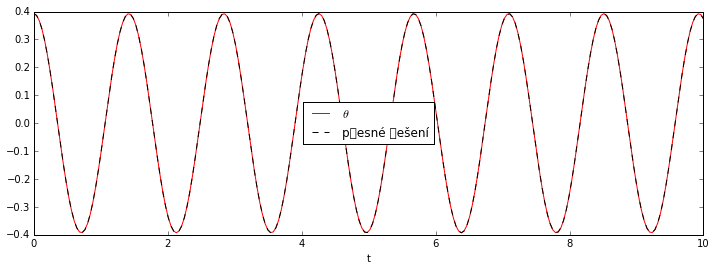

In [19]:
fig, axes = subplots(figsize=(12,4))
axes.plot(t, x[:, 0], 'r', label=r"$\theta$")
# axes.plot(t, x[:, 1], 'b', label=r"$d\theta / dt$")
axes.plot(t, x_anal, 'k--', label=u"přesné řešení")
axes.legend(loc="best")
axes.set_xlabel("t")

Podívejme se na frekvenční spektrum pomocí FFT.

In [20]:
import scipy.fftpack as fftpack

In [21]:
F = fftpack.fft(x[:,0])

In [22]:
# takto získáme frekvence
w = fftpack.fftfreq(F.shape[0], t[1] - t[0])
w_mask = w >= 0

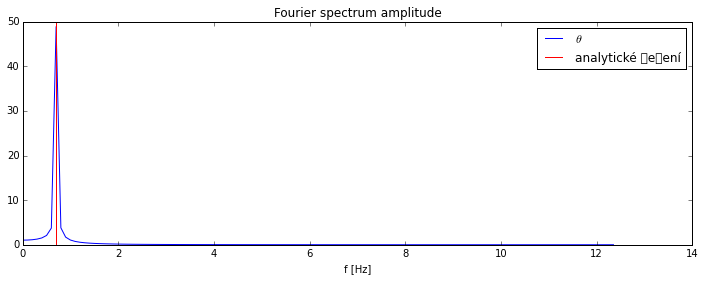

In [23]:
fig, ax = subplots(figsize=(12,4))
ax.plot(w[w_mask], abs(F[w_mask]), label=r"$\theta$")
ax.axvline(sqrt(g/L)/(2*pi), color='r', label=u"analytické řeěení")
ax.legend(loc="best")
ax.set_xlabel("f [Hz]")
ax.set_title("Fourier spectrum amplitude")

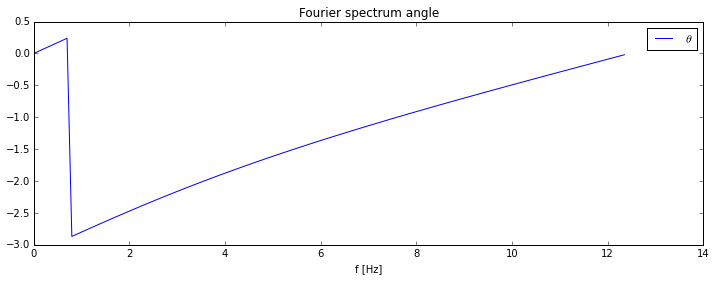

In [24]:
fig, ax = subplots(figsize=(12,4))
ax.plot(w[w_mask], angle(F[w_mask]), label=r"$\theta$")
# ax.axvline(sqrt(g/L)/(2*pi), color='r', label=u"analytické řeěení")
ax.legend(loc="best")
ax.set_xlabel("f [Hz]")
ax.set_title("Fourier spectrum angle")

#### Příklad 2: dvojité kyvadlo

Popis dvojitého kyvadla najdeme např. na Wikipedii: http://en.wikipedia.org/wiki/Double_pendulum

In [25]:
from IPython.display import Image
Image(url='http://upload.wikimedia.org/wikipedia/commons/c/c9/Double-compound-pendulum-dimensioned.svg')

Pohybové rovnice jso:

${\dot \theta_1} = \frac{6}{m\ell^2} \frac{ 2 p_{\theta_1} - 3 \cos(\theta_1-\theta_2) p_{\theta_2}}{16 - 9 \cos^2(\theta_1-\theta_2)}$

${\dot \theta_2} = \frac{6}{m\ell^2} \frac{ 8 p_{\theta_2} - 3 \cos(\theta_1-\theta_2) p_{\theta_1}}{16 - 9 \cos^2(\theta_1-\theta_2)}.$

${\dot p_{\theta_1}} = -\frac{1}{2} m \ell^2 \left [ {\dot \theta_1} {\dot \theta_2} \sin (\theta_1-\theta_2) + 3 \frac{g}{\ell} \sin \theta_1 \right ]$

${\dot p_{\theta_2}} = -\frac{1}{2} m \ell^2 \left [ -{\dot \theta_1} {\dot \theta_2} \sin (\theta_1-\theta_2) +  \frac{g}{\ell} \sin \theta_2 \right]$

Aby jsme si zjednodušili programování, použijeme notaci $x = [\theta_1, \theta_2, p_{\theta_1}, p_{\theta_2}]$, takže

${\dot x_1} = \frac{6}{m\ell^2} \frac{ 2 x_3 - 3 \cos(x_1-x_2) x_4}{16 - 9 \cos^2(x_1-x_2)}$

${\dot x_2} = \frac{6}{m\ell^2} \frac{ 8 x_4 - 3 \cos(x_1-x_2) x_3}{16 - 9 \cos^2(x_1-x_2)}$

${\dot x_3} = -\frac{1}{2} m \ell^2 \left [ {\dot x_1} {\dot x_2} \sin (x_1-x_2) + 3 \frac{g}{\ell} \sin x_1 \right ]$

${\dot x_4} = -\frac{1}{2} m \ell^2 \left [ -{\dot x_1} {\dot x_2} \sin (x_1-x_2) +  \frac{g}{\ell} \sin x_2 \right]$

In [26]:
from scipy.constants import g
L = 0.5
m = 0.1

def dx(x, t):
    """
    The right-hand side of the pendulum ODE
    """
    x1, x2, x3, x4 = x[0], x[1], x[2], x[3]
    
    dx1 = 6.0/(m*L**2) * (2 * x3 - 3 * cos(x1-x2) * x4)/(16 - 9 * cos(x1-x2)**2)
    dx2 = 6.0/(m*L**2) * (8 * x4 - 3 * cos(x1-x2) * x3)/(16 - 9 * cos(x1-x2)**2)
    dx3 = -0.5 * m * L**2 * ( dx1 * dx2 * sin(x1-x2) + 3 * (g/L) * sin(x1))
    dx4 = -0.5 * m * L**2 * (-dx1 * dx2 * sin(x1-x2) + (g/L) * sin(x2))
    
    return [dx1, dx2, dx3, dx4]

In [27]:
# počáteční stav
x0 = [pi/4, pi/2, 0, 0]

In [28]:
# časy pro řešení
t = linspace(0, 10, 250)

In [29]:
# a konečně řešení
x = odeint(dx, x0, t)

Nyní použijeme naší znalosti `matplotlib` a řešení si nakreslíme.

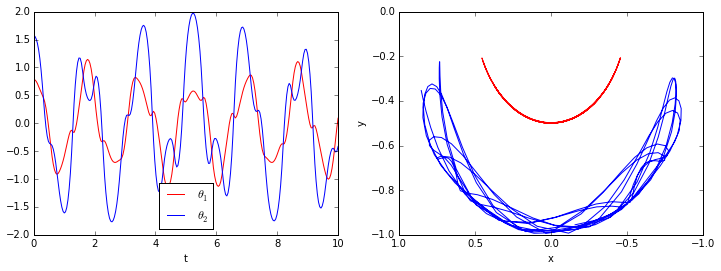

In [30]:
fig, axes = subplots(1,2, figsize=(12,4))
axes[0].plot(t, x[:, 0], 'r', label=r"$\theta_1$")
axes[0].plot(t, x[:, 1], 'b', label=r"$\theta_2$")
axes[0].legend(loc="best")
axes[0].set_xlabel("t")
# teď převedeme úhly na x, y souřadnice
x1 = + L * sin(x[:, 0])
y1 = - L * cos(x[:, 0])
x2 = x1 + L * sin(x[:, 1])
y2 = y1 - L * cos(x[:, 1])
# a opět nakreslíme    
axes[1].plot(x1, y1, 'r', label="pendulum1")
axes[1].plot(x2, y2, 'b', label="pendulum2")
axes[1].set_ylim([-1, 0])
axes[1].set_xlim([1, -1])
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

#### Fourierova transformace pomocí `fftpack`

In [33]:
import scipy.fftpack as fftpack

In [34]:
F = fftpack.fft(x[:,0])
F = hstack((F[:,newaxis], fftpack.fft(x[:,1])[:,newaxis]))

In [35]:
# takto získáme frekvence
w = fftpack.fftfreq(F.shape[0], t[1] - t[0])
w_mask = w >= 0

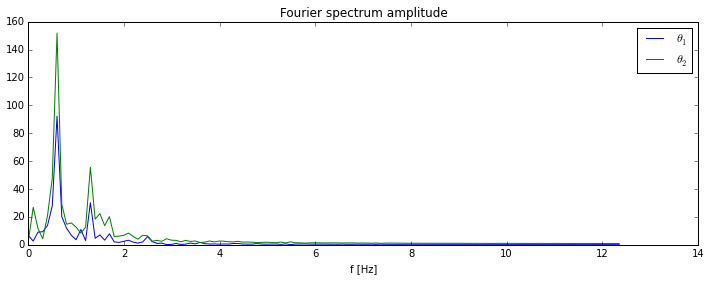

In [36]:
fig, ax = subplots(figsize=(12,4))
ax.plot(w[w_mask], abs(F[w_mask,0]), label=r"$\theta_1$")
ax.plot(w[w_mask], abs(F[w_mask,1]), label=r"$\theta_2$")
ax.legend(loc="best")
ax.set_xlabel("f [Hz]")
ax.set_title("Fourier spectrum amplitude")

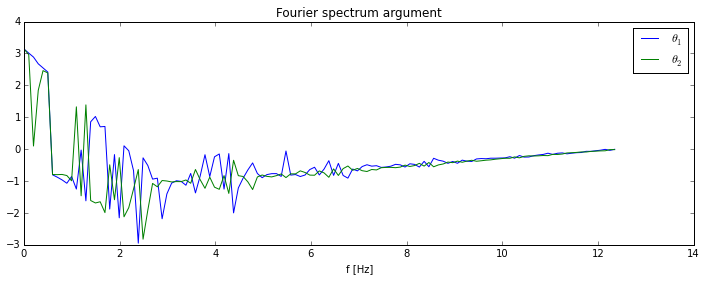

In [37]:
fig, ax = subplots(figsize=(12,4))
ax.plot(w[w_mask], angle(F[w_mask,0]), label=r"$\theta_1$")
ax.plot(w[w_mask], angle(F[w_mask,1]), label=r"$\theta_2$")
ax.legend(loc="best")
ax.set_xlabel("f [Hz]")
ax.set_title("Fourier spectrum argument")

## Lineární algebra

Modul `scipy.linalg` obsahuje velké množství nástrojů pro lineární algebru -- pro řešení lineárních rovnic, hledání vlastních čísel, různé dekompozice aj. Obsahuje také všechny funkce z `numpy.linalg`. Více informací viz http://docs.scipy.org/doc/scipy/reference/linalg.html.

In [38]:
import scipy.linalg

### Řešení soustavy lineárních rovnic


In [39]:
n_eq = 3
A = rand(n_eq, n_eq)
b = rand(n_eq)

Použijeme funkci `solve` na řešení soustavy.

In [40]:
x = sp.linalg.solve(A, b)

Stejné řešení pravděpodobně dostaneme pomocí inverzní matice.

In [41]:
xx = inv(A).dot(b)

Co a kdy bude rychlejší?

In [42]:
%%timeit
sp.linalg.solve(A, b)

The slowest run took 4.14 times longer than the fastest. This could mean that an intermediate result is being cached 
10000 loops, best of 3: 107 µs per loop


In [43]:
%%timeit
sp.linalg.inv(A).dot(b)

The slowest run took 252.75 times longer than the fastest. This could mean that an intermediate result is being cached 
10000 loops, best of 3: 88.9 µs per loop


Ještě zkontrolujeme řešení.

In [44]:
print("chyba solve = {}".format(norm(A.dot(x) - b)))
print("chyba inv   = {}".format(norm(A.dot(xx) - b)))

chyba solve = 1.1957467920563633e-15
chyba inv   = 4.742874840267547e-16


### Vlastní čísla

Vlastní čísla matice $A$ splňují rovnici $\displaystyle A v_n = \lambda_n v_n$, kde $v_n$ je $n$-tý vlastní vektor a $\lambda_n$ je $n$-té vlastní číslo.

`eigvals` najde vlastní čísla, `eig` zároveň i vlstní vektory.

In [45]:
sp.linalg.eigvals(A)

array([ 1.39306359+0.j        , -0.08351604+0.19177215j,
       -0.08351604-0.19177215j])

In [46]:
evals, evecs = sp.linalg.eig(A)

Vlastní vektory jsou ve sloupcích a v odpovídajícím pořadí k vlastním číslům. Můžeme si to jednoduše ověřit.

In [47]:
for n in range(len(evals)):
    print(norm(A.dot(evecs[:,n]) - evals[n] * evecs[:,n]))

6.37774571659e-16
2.78529828874e-16
2.78529828874e-16


## Řídké matice

Ŕídké matice osahují jen málé procento nenulových prvků, proto se vyplatí s nimi zacházet speciálním způsobem, včetně uložení v paměti. I s tímto nám SciPy může výrazně pomoci.

In [48]:
import scipy.sparse
import scipy.sparse.linalg

Řídkou matici můžeme vytvořit např. pomocí standardního array obejktu.

In [49]:
# řídká matice uložená běžným způsobem
M = array([[1,0,0,0], [0,3,0,0], [0,1,1,0], [1,0,0,1]])
print(M)

[[1 0 0 0]
 [0 3 0 0]
 [0 1 1 0]
 [1 0 0 1]]


In [50]:
# vytvoříme řídkou matici ve formátu CSR (compressed sparse row)
A = sp.sparse.csr_matrix(M)
print(A)

  (0, 0)	1
  (1, 1)	3
  (2, 1)	1
  (2, 2)	1
  (3, 0)	1
  (3, 3)	1


Efektivnější způsob, jak vyvořit řídkou matici, je vytvožit prázdnou a poté přidávat hodnoty pomocí indexů. Použijeme na to LIL (list of list) formát.

In [51]:
A = sp.sparse.lil_matrix((4,4))
A[0,0] = rand()
A[1,1] = rand()
A[1,2] = rand()
A[2,1] = rand()
A[2,2] = rand()
A[3,3] = rand()
print(A)

  (0, 0)	0.776677975006
  (1, 1)	0.977027539876
  (1, 2)	0.9640011903
  (2, 1)	0.7043782388
  (2, 2)	0.809460400756
  (3, 3)	0.337438878982


Takto vytvořenou matici převedeme do CSR formátu, který je obvykle efektivnější, a zkusíme vyřešit lineární systém pomocí konjugovaných gradientů (což nemusí vždy fungovat).

In [52]:
A = sp.sparse.csr_matrix(A)
b = rand(A.shape[1])
x, info = sp.sparse.linalg.cgs(A, b)

In [53]:
if info == 0:
    print("converged solution, error {:.2g}".format(norm(A * x - b)))
    print(x)
else:
    print("not converged, info = {}".format(info))

converged solution, error 6.4e-13
[ 0.17604879 -6.20887196  6.61827586  2.65608055]


## Interpolace a aproximace

Scipy nabízí jednoduché možnosti pro interpolaci a aproximaci dat.

In [54]:
import scipy.interpolate

### Příklad interpolace
Vyrobíme si nějaká zašuměná data pomocí známé funkce (např. sin) a zkusíme je interpolovat pomocí `interp1d`.

In [55]:
def f(x):
    return sin(x)

In [56]:
n = arange(0, 10)  
x = linspace(0, 9, 100)

y_meas = f(n) + 0.1 * randn(len(n))  # simulate measurement with noise
y_real = f(x)

linear_interpolation = sp.interpolate.interp1d(n, y_meas)
y_interp1 = linear_interpolation(x)

cubic_interpolation = sp.interpolate.interp1d(n, y_meas, kind='cubic')
y_interp2 = cubic_interpolation(x)

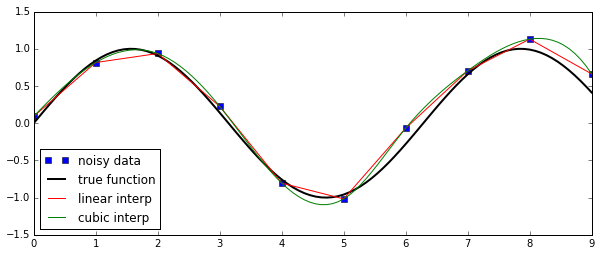

In [57]:
fig, ax = subplots(figsize=(10,4))
ax.plot(n, y_meas, 'bs', label='noisy data')
ax.plot(x, y_real, 'k', lw=2, label='true function')
ax.plot(x, y_interp1, 'r', label='linear interp')
ax.plot(x, y_interp2, 'g', label='cubic interp')
ax.legend(loc=3);

### Aproximace pomocí splajnů
Nyní se podívejme na splajny, které *aproximují* data, tj. nemusí procházet zadanými body.

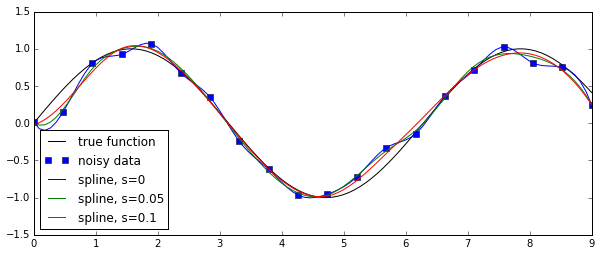

In [58]:
x = linspace(0, 9, 100)
n = linspace(x[0], x[-1], 20)
y_meas = f(n) + 0.1 * randn(len(n))  # simulate measurement with noise
y_real = f(x)

fig, ax = subplots(figsize=(10,4))
ax.plot(x, y_real, 'k', lw=1, label='true function')
ax.plot(n, y_meas, 'bs', label='noisy data')
for s in (0, 0.05, 0.1):
    spline_interpolation = sp.interpolate.UnivariateSpline(n, y_meas, k=3, s=s)
    y_spline = spline_interpolation(x)

    ax.plot(x, y_spline, label='spline, s={}'.format(s))
ax.legend(loc=3)

### Fit pomocí nejmenších čtverců
Tohle je trochu jiná úloha než interpolace nebo aproximace. Nyní máme předem danou funkci s neznámými parametry, o které předpokládáme, že popisuje naše data.

In [59]:
# fitování patří do optimalizace
import scipy.optimize

In [60]:
# předpokládáná funkce, a,b,c jsou neznámé parametry
def f_fit(x, a, b, c):
    return a*np.sin(b*x + c)

In [61]:
x = linspace(0, 9, 100)
n = linspace(x[0], x[-1], 20)
y_meas = sin(n) + 0.1 * randn(len(n))  # simulate measurement with noise
y_real = sin(x)

In [62]:
# počáteční odhad parametrů
guess = [1.3, 0.7, 1]
params, params_covariance = sp.optimize.curve_fit(f_fit, n, y_meas, guess)
print('výsledek: {:.3g} * sin({:.3g} * x {:+.3g})'.format(*params))

výsledek: 0.985 * sin(0.99 * x +0.0642)


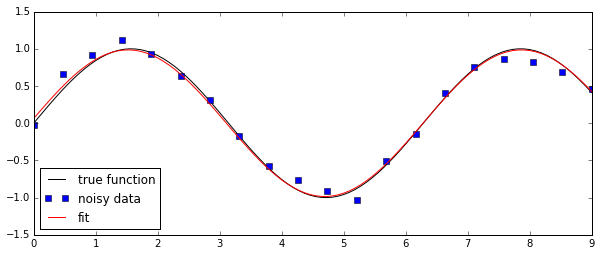

In [64]:
fig, ax = subplots(figsize=(10,4))
ax.plot(x, y_real, 'k', lw=1, label='true function')
ax.plot(n, y_meas, 'bs', label='noisy data')
ax.plot(x, f_fit(x, *params), 'r', label='fit')
ax.legend(loc=3)

## Zpracovnání obrazu

In [65]:
from scipy import ndimage, misc

In [66]:
lena = misc.lena()
lenas = [lena]
titles = ["original"]
lenas.append(ndimage.shift(lena, (50, 50)))
titles.append("shift")
lenas.append(ndimage.shift(lena, (50, 50), mode='nearest'))
titles.append("shift nearest")
lenas.append(ndimage.rotate(lena, 30))
titles.append("rotate")
lenas.append(lena[50:-50, 50:-50])
titles.append("crop")

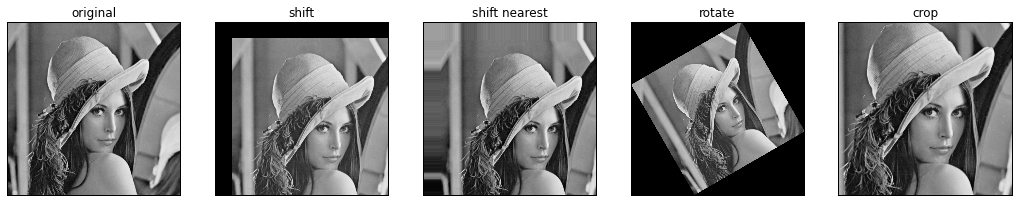

In [67]:
fig, axes = subplots(1, len(lenas), figsize=(18,6))
for ax, im, tit in zip(axes, lenas, titles):
    ax.imshow(im, cmap=cm.gray)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(tit)

In [68]:
from scipy import signal

noisy_lena = lena.copy().astype(np.float)
noisy_lena += lena.std()*1*np.random.standard_normal(lena.shape)
lenas = [noisy_lena]
titles = ["noisy"]
lenas.append(ndimage.gaussian_filter(noisy_lena, sigma=3))
titles.append("gaussian filter")
lenas.append(ndimage.median_filter(noisy_lena, size=5))
titles.append("median filter")
lenas.append(signal.wiener(noisy_lena, (5,5)))
titles.append("wiener filter")

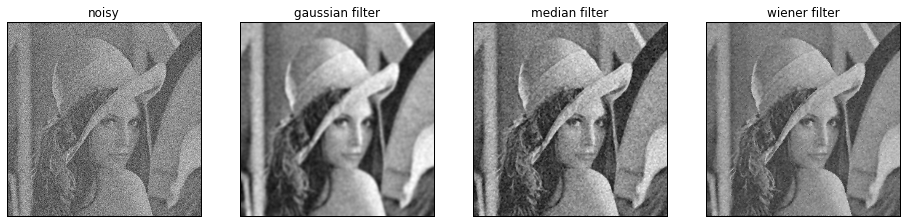

In [69]:
fig, axes = subplots(1, len(lenas), figsize=(16,5))
for ax, im, tit in zip(axes, lenas, titles):
    ax.imshow(im, cmap=cm.gray)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(tit)